<a href="https://colab.research.google.com/github/AI-Engineer-Abhi/Junior-AI-Engineer---Training/blob/main/Task-Day8/Web_scraping_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install requests feedparser beautifulsoup4 pandas openpyxl matplotlib --quiet

import requests
import feedparser
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://weworkremotely.com/categories/remote-programming-jobs.rss"

response = requests.get(URL)
print("Status Code:", response.status_code)    # 200 = successful

Status Code: 200


In [ ]:
# Parse the markup
# feedparser reads the raw XML/HTML response and turns it into
# a list of "entries" — one per job listing.
feed = feedparser.parse(response.content)
print("Listings found:", len(feed.entries))

Listings found: 25


In [ ]:
#  Extract the required information
records = []

for entry in feed.entries:
    # The site combines "Company: Job Title" into one field — split it apart
    if ":" in entry.title:
        company, job_title = entry.title.split(":", 1)
    else:
        company, job_title = "Unknown", entry.title

    # entry.summary is raw HTML (the job description) — BeautifulSoup
    # strips the tags so we're left with plain readable text
    description_text = BeautifulSoup(entry.summary, "html.parser").get_text(separator=" ", strip=True)

    records.append({
        "job_title": job_title.strip(),
        "company": company.strip(),
        "posting_date": entry.published,
        "apply_link": entry.link,
        "description": description_text[:300]   # trimmed, most of it is boilerplate
    })

print(f"Extracted {len(records)} job records")

Extracted 25 job records


In [ ]:
# Store the data in a DataFrame
df = pd.DataFrame(records)
df.head(10)

,job_title,company,posting_date,apply_link,description
0,Full Stack Web Developer ⏤ Remote Contractor,Abstract,"Thu, 11 Jun 2026 21:45:41 +0000",https://weworkremotely.com/remote-jobs/abstrac...,"Headquarters: Stuttgart, DE URL: http://theabs..."
1,//shiperp.com/: PHP Web Developer,https,"Thu, 11 Jun 2026 21:45:41 +0000",https://weworkremotely.com/remote-jobs/https-s...,"Headquarters: Shaw Blvd, Mandaluyong, Metro Ma..."
2,E-commerce Web Developer (Next.js / Node.js ex...,WorkStaff360,"Thu, 11 Jun 2026 21:45:40 +0000",https://weworkremotely.com/remote-jobs/worksta...,Headquarters: Islamabad URL: http://workstaff3...
3,Request for Proposals: Website Developer,Indigenous Climate Action,"Thu, 11 Jun 2026 21:45:40 +0000",https://weworkremotely.com/remote-jobs/indigen...,Headquarters: Canada URL: http://indigenouscli...
4,"Tax Analyst- Bloomington, IL",AHU Technologies,"Thu, 11 Jun 2026 18:33:07 +0000",https://weworkremotely.com/remote-jobs/ahu-tec...,Headquarters: Fully Remote - US URL: http://ah...
5,Framer Website Designer,Air Apps,"Thu, 11 Jun 2026 18:33:07 +0000",https://weworkremotely.com/remote-jobs/air-app...,Headquarters: Rome Metropolitain URL: http://a...
6,Localization Web Developer,NinjaOne,"Thu, 11 Jun 2026 18:33:07 +0000",https://weworkremotely.com/remote-jobs/ninjaon...,Headquarters: Remote URL: http://ninjaone.com ...
7,"Senior Technical Business Analyst- Atlanta, GA",AHU Technologies,"Thu, 11 Jun 2026 18:33:07 +0000",https://weworkremotely.com/remote-jobs/ahu-tec...,Headquarters: Fully Remote - US URL: http://ah...
8,Senior QA Engineer,Cortes 23,"Thu, 11 Jun 2026 18:02:55 +0000",https://weworkremotely.com/remote-jobs/cortes-...,Headquarters: Remote URL: https://cortes23.com...
9,Staff Software Engineer (Magic Containers),bunny.net,"Tue, 12 May 2026 12:34:46 +0000",https://weworkremotely.com/remote-jobs/bunny-n...,Headquarters: Slovenia URL: http://bunny.net S...


In [ ]:
# Data Cleaning
df = df.drop_duplicates(subset=["job_title", "company", "apply_link"])   # remove repeats
df["posting_date"] = pd.to_datetime(df["posting_date"], errors="coerce")  # real datetime, not text
df = df.dropna(subset=["job_title"])                                     # drop any broken rows
df = df.sort_values("posting_date", ascending=False).reset_index(drop=True)

print("After cleaning:", df.shape)
df.head(10)

After cleaning: (25, 5)


,job_title,company,posting_date,apply_link,description
0,Full Stack Web Developer ⏤ Remote Contractor,Abstract,2026-06-11 21:45:41+00:00,https://weworkremotely.com/remote-jobs/abstrac...,"Headquarters: Stuttgart, DE URL: http://theabs..."
1,//shiperp.com/: PHP Web Developer,https,2026-06-11 21:45:41+00:00,https://weworkremotely.com/remote-jobs/https-s...,"Headquarters: Shaw Blvd, Mandaluyong, Metro Ma..."
2,E-commerce Web Developer (Next.js / Node.js ex...,WorkStaff360,2026-06-11 21:45:40+00:00,https://weworkremotely.com/remote-jobs/worksta...,Headquarters: Islamabad URL: http://workstaff3...
3,Request for Proposals: Website Developer,Indigenous Climate Action,2026-06-11 21:45:40+00:00,https://weworkremotely.com/remote-jobs/indigen...,Headquarters: Canada URL: http://indigenouscli...
4,"Tax Analyst- Bloomington, IL",AHU Technologies,2026-06-11 18:33:07+00:00,https://weworkremotely.com/remote-jobs/ahu-tec...,Headquarters: Fully Remote - US URL: http://ah...
5,Framer Website Designer,Air Apps,2026-06-11 18:33:07+00:00,https://weworkremotely.com/remote-jobs/air-app...,Headquarters: Rome Metropolitain URL: http://a...
6,Localization Web Developer,NinjaOne,2026-06-11 18:33:07+00:00,https://weworkremotely.com/remote-jobs/ninjaon...,Headquarters: Remote URL: http://ninjaone.com ...
7,"Senior Technical Business Analyst- Atlanta, GA",AHU Technologies,2026-06-11 18:33:07+00:00,https://weworkremotely.com/remote-jobs/ahu-tec...,Headquarters: Fully Remote - US URL: http://ah...
8,Senior QA Engineer,Cortes 23,2026-06-11 18:02:55+00:00,https://weworkremotely.com/remote-jobs/cortes-...,Headquarters: Remote URL: https://cortes23.com...
9,Senior Web Developer (WordPress & Shopify),Rehire,2026-06-10 15:59:08+00:00,https://weworkremotely.com/remote-jobs/rehire-...,Headquarters: Colombia URL: http://rehiresolut...


In [ ]:
# Exploratory Data Analysis
print("\nTop hiring companies:")
print(df["company"].value_counts().head(10))

print("\nListings per day (most recent):")
print(df["posting_date"].dt.date.value_counts().head(5))


Top hiring companies:
company
AHU Technologies             5
A.Team                       2
Abstract                     1
https                        1
Indigenous Climate Action    1
WorkStaff360                 1
NinjaOne                     1
Air Apps                     1
Rehire                       1
Olsson                       1
Name: count, dtype: int64

Listings per day (most recent):
posting_date
2026-06-11    9
2026-06-08    6
2026-06-10    4
2024-06-16    2
2026-06-09    1
Name: count, dtype: int64


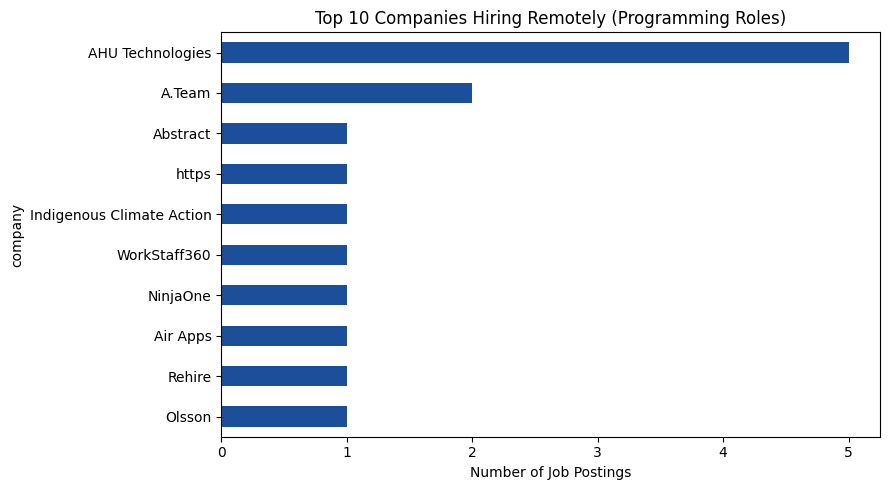

In [ ]:
# Data Visualization
top_companies = df["company"].value_counts().head(10)

plt.figure(figsize=(9, 5))
top_companies.plot(kind="barh", color="#1B4F9C")
plt.title("Top 10 Companies Hiring Remotely (Programming Roles)")
plt.xlabel("Number of Job Postings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Export the final dataset
df.to_csv("/content/remote_job_market.csv", index=False)
df['posting_date'] = df['posting_date'].dt.tz_localize(None) # Make datetime objects timezone-unaware
df.to_excel("/content/remote_job_market.xlsx", index=False)

from google.colab import files
files.download("remote_job_market.csv")

print("\nDone. Dataset saved as remote_job_market.csv and remote_job_market.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done. Dataset saved as remote_job_market.csv and remote_job_market.xlsx
